# British Grand Prix - 2026 🇬🇧 | The Sprint Race

- This notebook is full post-race technical debrief of the Sprint Race - 2026.

## Necessary Imports

In [1]:
# FastF1 Deps
import fastf1

# Data Deps
import pandas as pd

# Visualisation Deps
import matplotlib.pyplot as plt
from plotly.offline import init_notebook_mode

# Core Deps
from pathlib import Path
import sys
sys.path.append(str(Path("../../")))

# Source Deps
from mark_1 import DataLoader, DataPipeline, DataVisualisation
from mark_1.config import CarSpecifications, RaceStrategyConfig

# Plotly Notebook Orchestration
init_notebook_mode(connected=True)

## Notebook-Level Setup and Configurations

In [2]:
# Accessing the Current Working Directory for Absolute Root Path
REPO_ROOT_PATH = Path.cwd().parent.parent.parent

# Pathlib Path Objects for the Notebook
F1_PATH = REPO_ROOT_PATH / "F1"
F1_DATA_PATH = F1_PATH / "data"
CACHE_PATH = F1_PATH / "cache"
CACHE_PATH.mkdir(exist_ok=True)

# Adding the source scripts into the Python Execution Path
if F1_PATH not in sys.path:
    sys.path.append(str(F1_PATH))

## Loading the Event

In [3]:
# Defaulting the Requests for Caching to a Predefined path
# fastf1.Cache.clear_cache(cache_dir=str(CACHE_PATH))
fastf1.Cache.enable_cache(cache_dir=str(CACHE_PATH))

# Enabling Offline Mode
fastf1.Cache.offline_mode(enabled=True)

# The GP Event
britain_2026 = fastf1.get_event(
    year=2026,
    gp="britain"
)
print(britain_2026)

events      WARNING 	Correcting user input 'britain' to 'British Grand Prix'


RoundNumber                                                  9
Country                                         United Kingdom
Location                                           Silverstone
OfficialEventName    FORMULA 1 PIRELLI BRITISH GRAND PRIX 2026
EventDate                                  2026-07-05 00:00:00
EventName                                   British Grand Prix
EventFormat                                  sprint_qualifying
Session1                                            Practice 1
Session1Date                         2026-07-03 12:30:00+01:00
Session1DateUtc                            2026-07-03 11:30:00
Session2                                     Sprint Qualifying
Session2Date                         2026-07-03 16:30:00+01:00
Session2DateUtc                            2026-07-03 15:30:00
Session3                                                Sprint
Session3Date                         2026-07-04 12:00:00+01:00
Session3DateUtc                            2026-07-04 1

In [4]:
britain_2026 = DataLoader(race_event=britain_2026)
gp_weekend = britain_2026.load_data(is_sprint=True)

core           INFO 	Loading data for British Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '16', '44', '63', '6', '1', '3', '81', '41', '30', '5', '10', '27', '87', '55', '23', '31', '77', '43', '11', '18', '14']
core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Usi

In [5]:
# Decompiling the Data
race = gp_weekend.sprint_session

In [6]:
# Loading the Performance data from Quali
quali_performance = pd.read_csv(F1_DATA_PATH / "sprint_quali_performance_britain.csv")
quali_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,ANT,28.094,35.750,24.543,88.387,302.0,268.0,249.0,301.0,0.278701,0.247019,0.229499,-17.959722,559.253241,851.820988,-0.639273,15.643447,34.707289,1.123134,8.224956
1,HAM,28.113,35.706,24.557,88.376,300.0,267.0,241.0,298.0,0.279453,0.248881,0.224234,-35.621605,521.665895,915.052315,-1.267087,14.610035,37.262382,1.116105,8.283186
2,LEC,28.159,35.841,24.703,88.703,300.0,267.0,243.0,300.0,0.277137,0.246291,0.223260,0.000000,557.287500,921.843056,0.000000,15.548883,37.317049,1.123596,8.253968
3,NOR,28.291,35.937,24.512,88.740,299.0,270.0,244.0,304.0,0.271307,0.245125,0.222953,89.798611,581.263580,979.296296,3.174105,16.174516,39.951709,1.125926,8.153310
4,RUS,28.301,35.854,24.578,88.733,295.0,267.0,247.0,299.0,0.272057,0.247025,0.228852,70.766667,539.446914,845.625926,2.500501,15.045655,34.405807,1.119850,8.268551


## Data Engineering

<img src="../../../assets/circuit_maps/silverstone_map.avif">

In [7]:
# Instantiating the Data Pipeline
data_pipe = DataPipeline(circuit="britain")

# Full Laps Frame
assert race, "Race was not loaded"
race_laps_full = race.laps

# Total no of laps in the race
max_laps = race.laps["LapNumber"].max()

# Drop columns
drop_cols = [
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", 
    "DeletedReason", "FastF1Generated", "IsAccurate",
    "LapStartDate", "LapStartTime"
]

# Filtered Laps
filtered_race_laps = race_laps_full.drop(drop_cols, axis=1)

# Calculating the Driver Deltas
filtered_race_laps = data_pipe.get_traffic_delta(laps_frame=filtered_race_laps)

# Rounding down to the top runners
top_5_drivers = race.results.iloc[:5]["Abbreviation"]
filtered_race_laps = filtered_race_laps.pick_drivers(top_5_drivers.to_list())
filtered_race_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta
0,0 days 00:49:09.819000,ANT,12,NaT,1.0,1.0,NaT,NaT,NaT,0 days 00:00:38.780000,...,317.0,False,MEDIUM,1.0,True,Mercedes,1,2.0,False,1.071
1,0 days 00:50:42.200000,ANT,12,0 days 00:01:32.381000,2.0,1.0,NaT,NaT,0 days 00:00:29.664000,0 days 00:00:37.183000,...,301.0,True,MEDIUM,2.0,True,Mercedes,12,2.0,False,1.337
2,0 days 00:52:14.530000,ANT,12,0 days 00:01:32.330000,3.0,1.0,NaT,NaT,0 days 00:00:29.633000,0 days 00:00:37.217000,...,303.0,True,MEDIUM,3.0,True,Mercedes,1,2.0,False,1.123
3,0 days 00:53:46.500000,ANT,12,0 days 00:01:31.970000,4.0,1.0,NaT,NaT,0 days 00:00:29.446000,0 days 00:00:37.273000,...,303.0,True,MEDIUM,4.0,True,Mercedes,1,2.0,False,0.874
4,0 days 00:55:18.475000,ANT,12,0 days 00:01:31.975000,5.0,1.0,NaT,NaT,0 days 00:00:29.367000,0 days 00:00:37.193000,...,308.0,False,MEDIUM,5.0,True,Mercedes,1,2.0,False,0.941


In [8]:
# Transforming all the timedelta objects
get_seconds = pd.Timedelta.total_seconds

filtered_race_laps["LapTime"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["LapTime"]),
    axis=1
)
filtered_race_laps["Sector1Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector1Time"]),
    axis=1
)
filtered_race_laps["Sector2Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector2Time"]),
    axis=1
)
filtered_race_laps["Sector3Time"] = filtered_race_laps.apply(
    lambda x: get_seconds(x["Sector3Time"]),
    axis=1
)

# Picking all the green flag laps without boxing
filtered_race_laps_wo = (
    filtered_race_laps
    .pick_wo_box()
    .pick_track_status(status="1")
    .copy()
)
filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta
0,0 days 00:49:09.819000,ANT,12,NaN,1.0,1.0,NaT,NaT,NaN,38.780,...,317.0,False,MEDIUM,1.0,True,Mercedes,1,2.0,False,1.071
2,0 days 00:52:14.530000,ANT,12,92.330,3.0,1.0,NaT,NaT,29.633,37.217,...,303.0,True,MEDIUM,3.0,True,Mercedes,1,2.0,False,1.123
3,0 days 00:53:46.500000,ANT,12,91.970,4.0,1.0,NaT,NaT,29.446,37.273,...,303.0,True,MEDIUM,4.0,True,Mercedes,1,2.0,False,0.874
4,0 days 00:55:18.475000,ANT,12,91.975,5.0,1.0,NaT,NaT,29.367,37.193,...,308.0,False,MEDIUM,5.0,True,Mercedes,1,2.0,False,0.941
5,0 days 00:56:50.579000,ANT,12,92.104,6.0,1.0,NaT,NaT,29.434,37.345,...,309.0,False,MEDIUM,6.0,True,Mercedes,1,2.0,False,0.736


### Engineering the Aero Features
A comparison of the average speed (weighted by sector time) carried by each of the drivers and teams through the lap. The Silverstone Circuit (one of my favourite tracks ✨), has always been a High-Speed, High-Energy track layout that can be broken as follows:
1. `Front-Axle | High Speed & Medium Downforce` **Sector - 1**: Generically, due to the high-speed nature of the circuit the main tradeoff in setup is always the decision of Downforce (high-speed corners) and Drag (medium-long straights). However, the first sector, is argually one of the highest energy sections on the circuit through turns 1-3 (Abbey, Farm and Village) followed by the Wellington Straight. Thus, to gain time, a car needs to have sufficienty front-end at high-speed.
2. `Balanced | Downforce - Drag Tradeoff` **Sector - 2**: Requires sufficient traction for turns 6-7 😂 (Brooklands and Luffield) followed by another high-speed section through turns 9-14 (Copse, Maggotts, Becketts and Chapel). However, with the current generation of cars, this section is nowhere near as fast as it used to be. Hence a balanced setup is necessary to provide traction while harvesting and carrying the maximum speed possible through the corners.l
3. `Rear-Axle | Drag & Traction` **Sector - 3**: At this, the tyres loose most of their grip and have two long straights before the end of the lap with Stowe (the only real high-energy corner). Thus, a setup with the best traction delivery will perform grip is essential to gain straight line speed while deployment is a bonus.

In [9]:
# Sector - 1: Rear Axle Load
filtered_race_laps_wo.loc[:, "FrontAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 2: Balanced Load
filtered_race_laps_wo.loc[:, "BalancedAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 3: Front Axle Load
filtered_race_laps_wo.loc[:, "RearAEI"] = data_pipe.get_aero_efficiency(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TyreLife,FreshTyre,Team,TrackStatus,Position,Deleted,TrafficDelta,FrontAEI,BalancedAEI,RearAEI
0,0 days 00:49:09.819000,ANT,12,NaN,1.0,1.0,NaT,NaT,NaN,38.780,...,1.0,True,Mercedes,1,2.0,False,1.071,NaN,0.220092,0.221100
2,0 days 00:52:14.530000,ANT,12,92.330,3.0,1.0,NaT,NaT,29.633,37.217,...,3.0,True,Mercedes,1,2.0,False,1.123,0.269833,0.237215,0.227766
3,0 days 00:53:46.500000,ANT,12,91.970,4.0,1.0,NaT,NaT,29.446,37.273,...,4.0,True,Mercedes,1,2.0,False,0.874,0.280690,0.236859,0.231642
4,0 days 00:55:18.475000,ANT,12,91.975,5.0,1.0,NaT,NaT,29.367,37.193,...,5.0,True,Mercedes,1,2.0,False,0.941,0.281385,0.236189,0.221104
5,0 days 00:56:50.579000,ANT,12,92.104,6.0,1.0,NaT,NaT,29.434,37.345,...,6.0,True,Mercedes,1,2.0,False,0.736,0.280733,0.231812,0.225595


### Engineering the Kinetic Energy Features

In [10]:
# Sector - 1
filtered_race_laps_wo.loc[:, "KineticEnergyS1_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 2
filtered_race_laps_wo.loc[:, "KineticEnergyS2_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 3
filtered_race_laps_wo.loc[:, "KineticEnergyS3_KJ"] = data_pipe.get_delta_kinetic_energy(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrackStatus,Position,Deleted,TrafficDelta,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ
0,0 days 00:49:09.819000,ANT,12,NaN,1.0,1.0,NaT,NaT,NaN,38.780,...,1,2.0,False,1.071,NaN,0.220092,0.221100,130.721759,901.381481,1071.418056
2,0 days 00:52:14.530000,ANT,12,92.330,3.0,1.0,NaT,NaT,29.633,37.217,...,1,2.0,False,1.123,0.269833,0.237215,0.227766,107.222222,689.945216,812.893364
3,0 days 00:53:46.500000,ANT,12,91.970,4.0,1.0,NaT,NaT,29.446,37.273,...,1,2.0,False,0.874,0.280690,0.236859,0.231642,-72.672840,689.945216,782.513735
4,0 days 00:55:18.475000,ANT,12,91.975,5.0,1.0,NaT,NaT,29.367,37.193,...,1,2.0,False,0.941,0.281385,0.236189,0.221104,-73.864198,733.846759,963.927778
5,0 days 00:56:50.579000,ANT,12,92.104,6.0,1.0,NaT,NaT,29.434,37.345,...,1,2.0,False,0.736,0.280733,0.231812,0.225595,-74.102469,799.311883,907.100000


### Engineering the Power Features

In [11]:
# Sector - 1
filtered_race_laps_wo.loc[:, "PowerS1_KW"] = data_pipe.get_power_expenditure(
    sector="Sector1",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 2
filtered_race_laps_wo.loc[:, "PowerS2_KW"] = data_pipe.get_power_expenditure(
    sector="Sector2",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

# Sector - 3
filtered_race_laps_wo.loc[:, "PowerS3_KW"] = data_pipe.get_power_expenditure(
    sector="Sector3",
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

filtered_race_laps_wo.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrafficDelta,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW
0,0 days 00:49:09.819000,ANT,12,NaN,1.0,1.0,NaT,NaT,NaN,38.780,...,1.071,NaN,0.220092,0.221100,130.721759,901.381481,1071.418056,NaN,23.243463,42.704694
2,0 days 00:52:14.530000,ANT,12,92.330,3.0,1.0,NaT,NaT,29.633,37.217,...,1.123,0.269833,0.237215,0.227766,107.222222,689.945216,812.893364,3.618338,18.538443,31.903193
3,0 days 00:53:46.500000,ANT,12,91.970,4.0,1.0,NaT,NaT,29.446,37.273,...,0.874,0.280690,0.236859,0.231642,-72.672840,689.945216,782.513735,-2.468004,18.510590,30.989416
4,0 days 00:55:18.475000,ANT,12,91.975,5.0,1.0,NaT,NaT,29.367,37.193,...,0.941,0.281385,0.236189,0.221104,-73.864198,733.846759,963.927778,-2.515211,19.730776,37.927514
5,0 days 00:56:50.579000,ANT,12,92.104,6.0,1.0,NaT,NaT,29.434,37.345,...,0.736,0.280733,0.231812,0.225595,-74.102469,799.311883,907.100000,-2.517581,21.403451,35.818361


### Engineering the Fuel and Pace Features

In [12]:
# Instances of all the configs
car_spec = CarSpecifications()
race_spec = RaceStrategyConfig()

In [13]:
# Engineering all the pace features using the pipeline
driver_fuel_flow = {}

mean_race_laps = data_pipe.get_mean_race_laps(
    laps_frame=filtered_race_laps_wo,
    drivers=top_5_drivers.to_list()
)

effective_fuel_load = data_pipe.get_effective_fuel_load(
    max_fuel_load_in_kg=car_spec.MAX_FUEL_LOAD_IN_KG,
    fuel_sample_limit=race_spec.FUEL_SAMPLE_LIMIT,
    fuel_strat=race_spec.FUEL_STRAT
)

for _, row in mean_race_laps.iterrows():
    fuel_flow = data_pipe.get_effective_fuel_flow(
        effective_fuel_load=effective_fuel_load,
        avg_laptime=row["LapTime"],
        race_laps=max_laps
    )
    driver_fuel_flow[row["Driver"]] = fuel_flow

driver_fuel_flow

{'ANT': np.float64(39.55043320269924),
 'HAM': np.float64(39.434057669129174),
 'LEC': np.float64(39.31709337268537),
 'NOR': np.float64(39.35122939799178),
 'RUS': np.float64(39.33761879326398)}

In [14]:
# LapFuelBurn: Fuel burnt over a single lap based on laptime
filtered_race_laps_wo.loc[:, "LapFuelBurn"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_lap_fuel_burn(
        laptime=x["LapTime"],
        effective_fuel_flow=driver_fuel_flow[x["Driver"]]
    ), 
    axis=1
)

# CumulativeFuelBurn: The fuel burnt over the race distance based on laptimes
filtered_race_laps_wo.loc[:, "CumulativeFuelBurn"] = (
    filtered_race_laps_wo
    .groupby("Driver")["LapFuelBurn"]
    .cumsum()
)

# LapFuelPenality: Zero-Fuel Pace for each race lap based on the cumulative fuel burn offset
filtered_race_laps_wo.loc[:, "LapFuelPenality"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_lap_fuel_penality(
        cumulative_fuel_burn=x["CumulativeFuelBurn"],
        effective_fuel_load=effective_fuel_load
    ),
    axis=1
)

# FuelAwareLapTime: Final Zero-Fuel laptime within the assumed parameters
filtered_race_laps_wo["FuelAwareLapTime"] = filtered_race_laps_wo.apply(
    lambda x: data_pipe.get_fuel_aware_laptime(
        laptime=x["LapTime"], 
        fuel_penality=x["LapFuelPenality"]
    ),
    axis=1
)
filtered_race_laps_wo.tail()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,LapFuelBurn,CumulativeFuelBurn,LapFuelPenality,FuelAwareLapTime
80,0 days 01:07:48.185000,LEC,16,92.333,13.0,1.0,NaT,NaT,29.779,36.977,...,196.901698,775.454938,882.409105,6.612099,20.971278,34.500102,3.630265,40.165320,0.655040,91.677960
81,0 days 01:09:20.774000,LEC,16,92.589,14.0,1.0,NaT,NaT,29.940,37.272,...,213.014815,692.387500,876.094907,7.114723,18.576612,34.523187,3.640330,43.805651,0.545830,92.043170
82,0 days 01:10:53.366000,LEC,16,92.592,15.0,1.0,NaT,NaT,30.037,37.024,...,124.467130,703.020370,854.918519,4.143794,18.988234,33.485509,3.640448,47.446099,0.436617,92.155383
83,0 days 01:12:25.855000,LEC,16,92.489,16.0,1.0,NaT,NaT,29.862,36.990,...,142.486420,751.895833,872.937809,4.771496,20.327003,34.049920,3.636399,51.082498,0.327525,92.161475
84,0 days 01:13:58.013000,LEC,16,92.158,17.0,1.0,NaT,NaT,29.835,36.900,...,380.906944,863.734568,1078.893827,12.767117,23.407441,42.437707,3.623385,54.705882,0.218824,91.939176


In [15]:
max_fuel_burns = filtered_race_laps_wo.groupby("Driver")["CumulativeFuelBurn"].last().reset_index()

# Sanity Check for Fuel Load
print(f"Effective Fuel Load: {effective_fuel_load}")

print("\nDriver | Max Fuel Burn")
for _, row in max_fuel_burns.iterrows():
    print(row["Driver"], " | ", row["CumulativeFuelBurn"])

Effective Fuel Load: 62

Driver | Max Fuel Burn
ANT  |  54.70588235294117
HAM  |  54.705882352941174
LEC  |  54.70588235294117
NOR  |  54.70588235294118
RUS  |  54.705882352941174


## Data Visualisation

In [16]:
# Instantiating the Data Visualisation Handle
assert race is not None, "The race session wasn't loaded"

data_vis = DataVisualisation(
    session=race,
    driver_names=top_5_drivers.to_list(),
    circuit="britain"
)

req            INFO 	Using cached data for driver_info


### Simple Tyre Degradation Plots

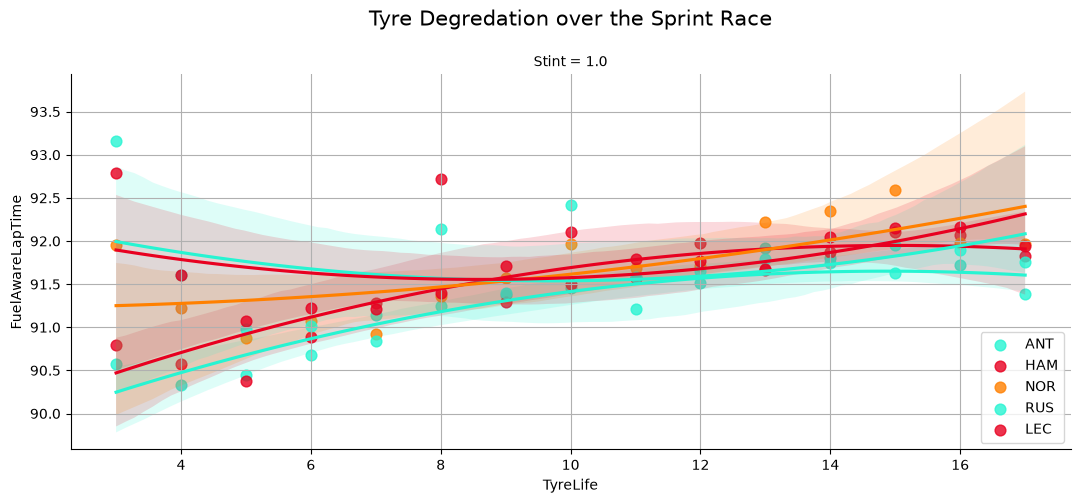

In [17]:
pace_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="FuelAwareLapTime",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

pace_deg_grid.figure.suptitle(
    "Tyre Degredation over the Sprint Race",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.85, hspace=0.2)
plt.show()

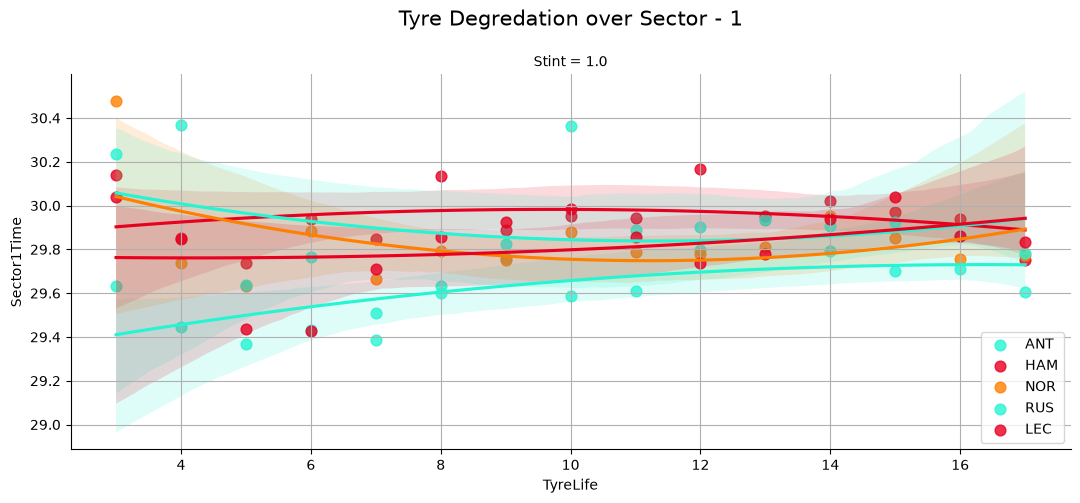

In [18]:
sector1_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector1Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector1_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 1",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.85, hspace=0.2)
plt.show()

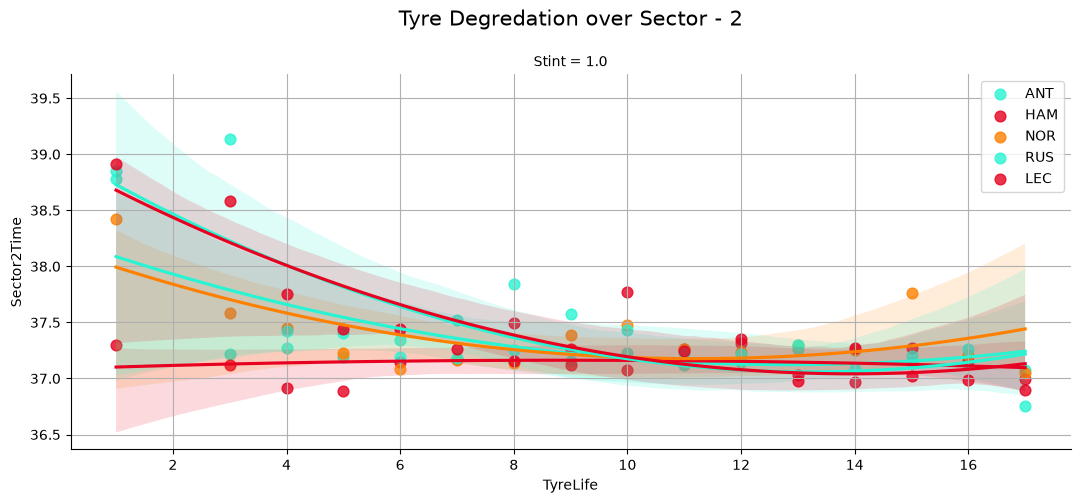

In [19]:
sector2_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector2Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector2_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 2",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.85, hspace=0.2)
plt.show()

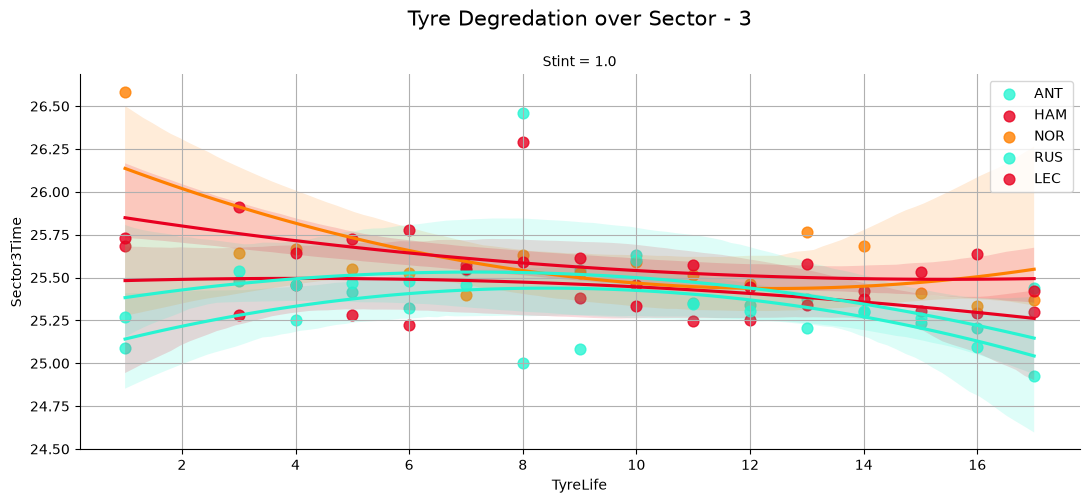

In [20]:
sector3_deg_grid = data_vis.create_degradation_plot(
    laps_frame=filtered_race_laps_wo,
    x="TyreLife",
    y="Sector3Time",
    order=2,
    hue="Driver",
    height=5,
    aspect=2.5,
    row="Stint"
)

sector3_deg_grid.figure.suptitle(
    "Tyre Degredation over Sector - 3",
    fontsize=15
)
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.85, hspace=0.2)
plt.legend(loc="upper right")
plt.show()

### Raw Pace Plots

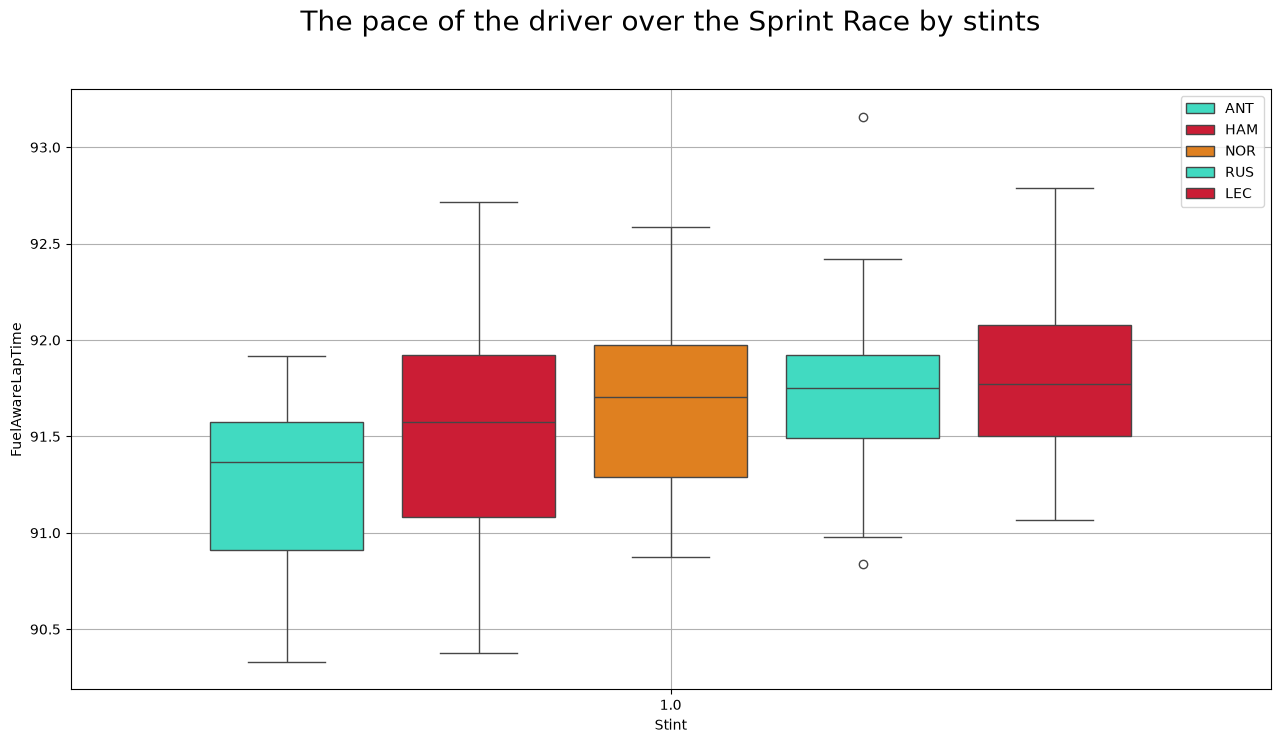

In [21]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="FuelAwareLapTime",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver over the Sprint Race by stints",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

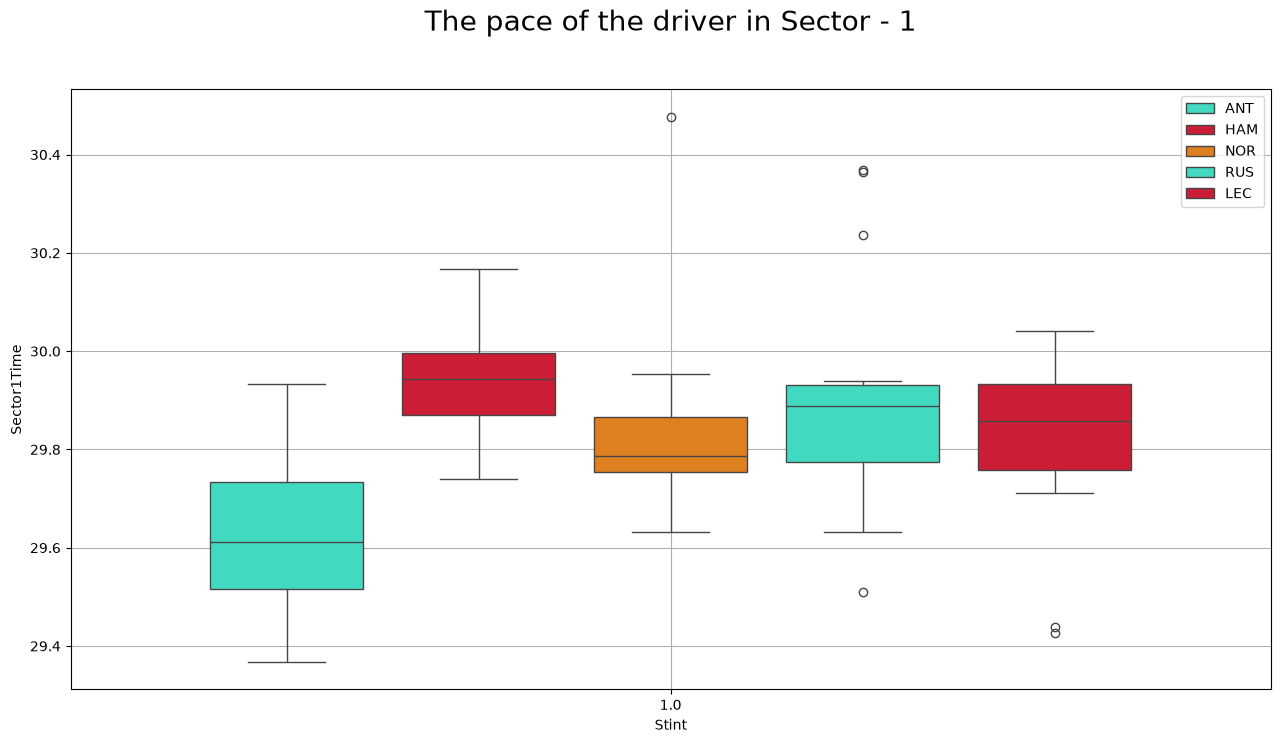

In [22]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector1Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 1",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

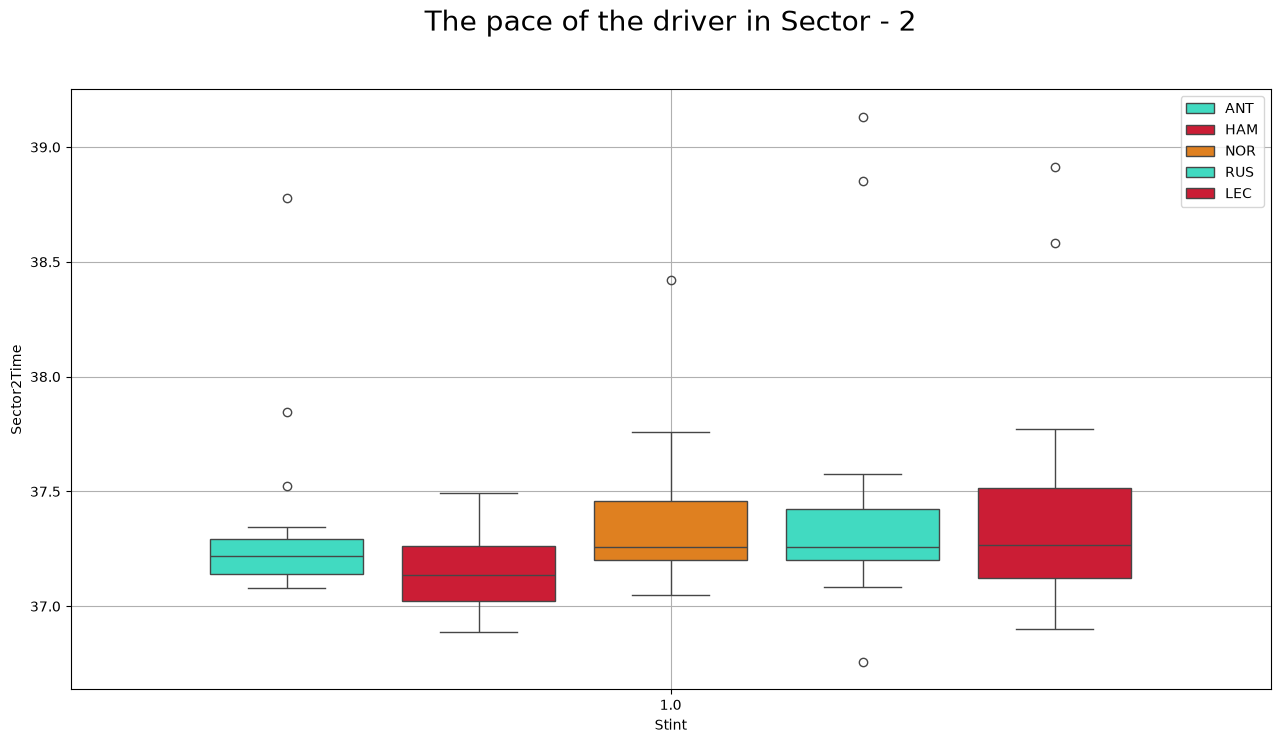

In [23]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector2Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 2",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

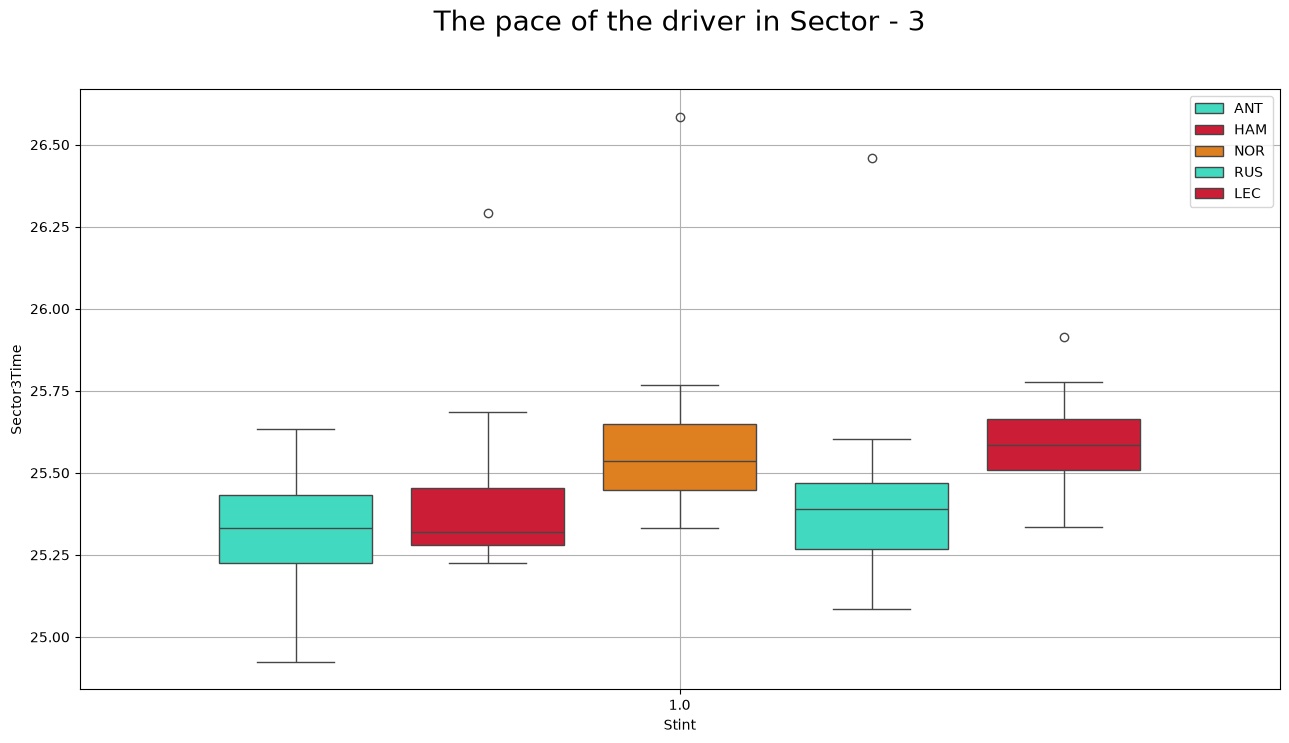

In [24]:
pace_grid = data_vis.create_pace_plot(
    laps_frame=filtered_race_laps_wo,
    x="Stint",
    y="Sector3Time",
    hue="Driver",
    figsize=(30, 10)
)

pace_grid.figure.suptitle(
    t="The pace of the driver in Sector - 3",
    fontsize=20
)
plt.subplots_adjust(left=0.3, right=0.7, top=0.9, bottom=0.3)
plt.show()

### KE Retention Plots

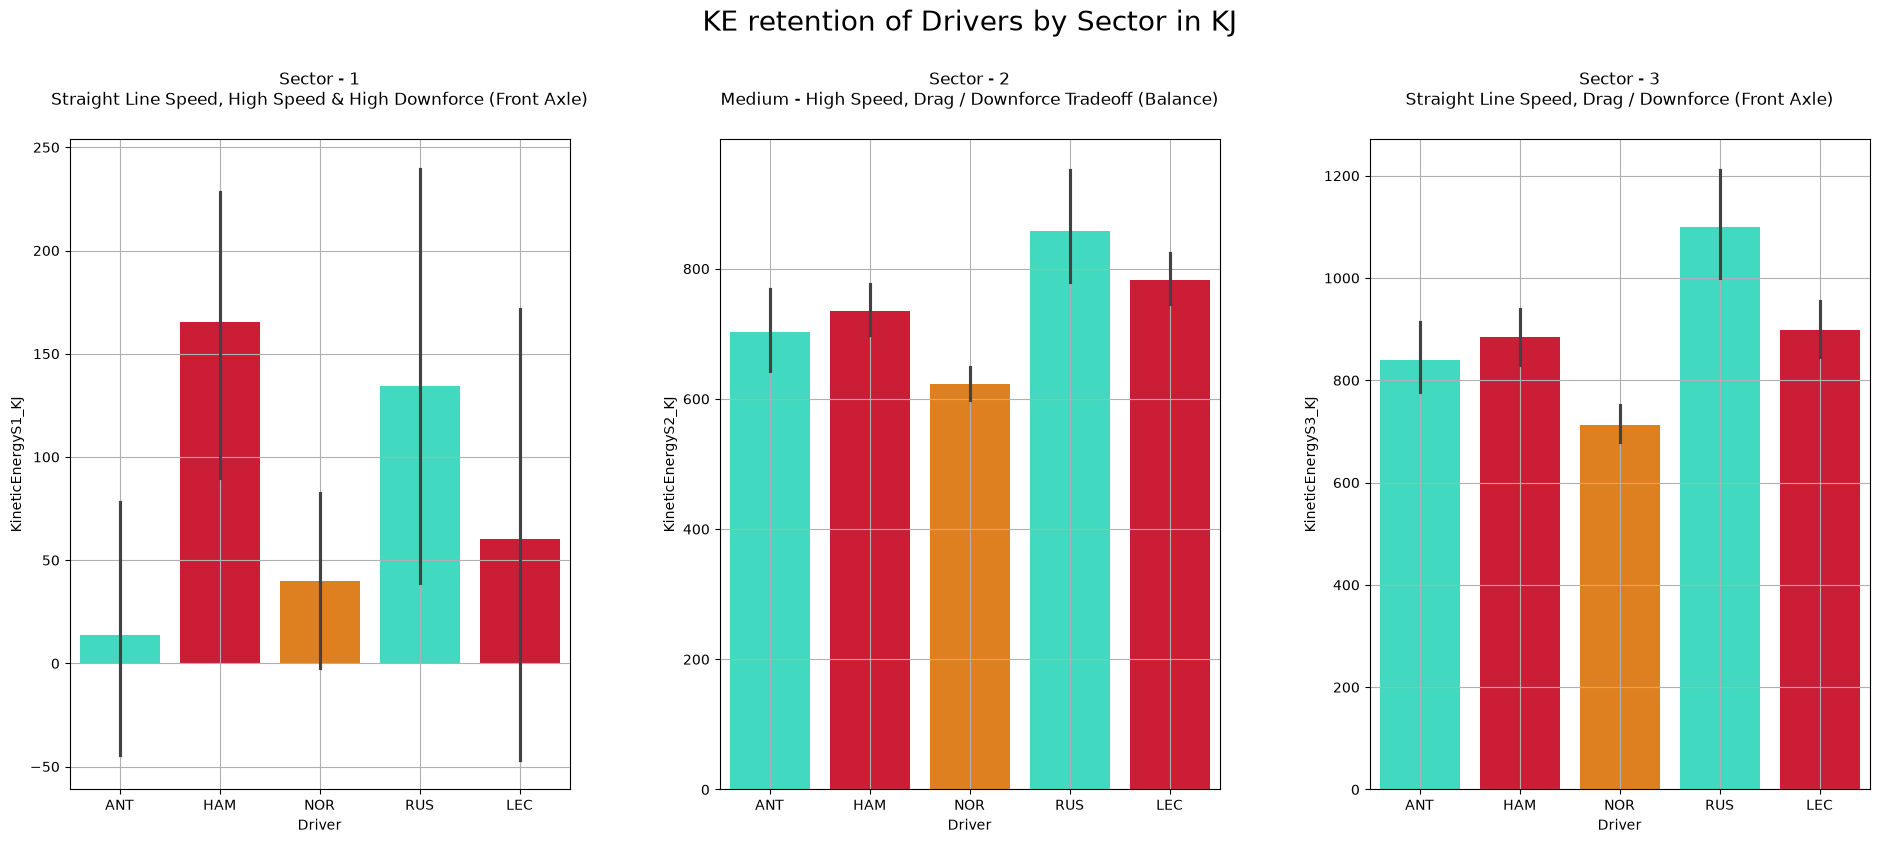

In [25]:
ke_grid = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=filtered_race_laps_wo,
    hue="Driver",
    plot_kind="ke"
)

ke_grid.suptitle(
    t="KE retention of Drivers by Sector in KJ",
    fontsize=20
)
plt.subplots_adjust(
    left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.3
)
plt.show()

### Power Deployment Plots

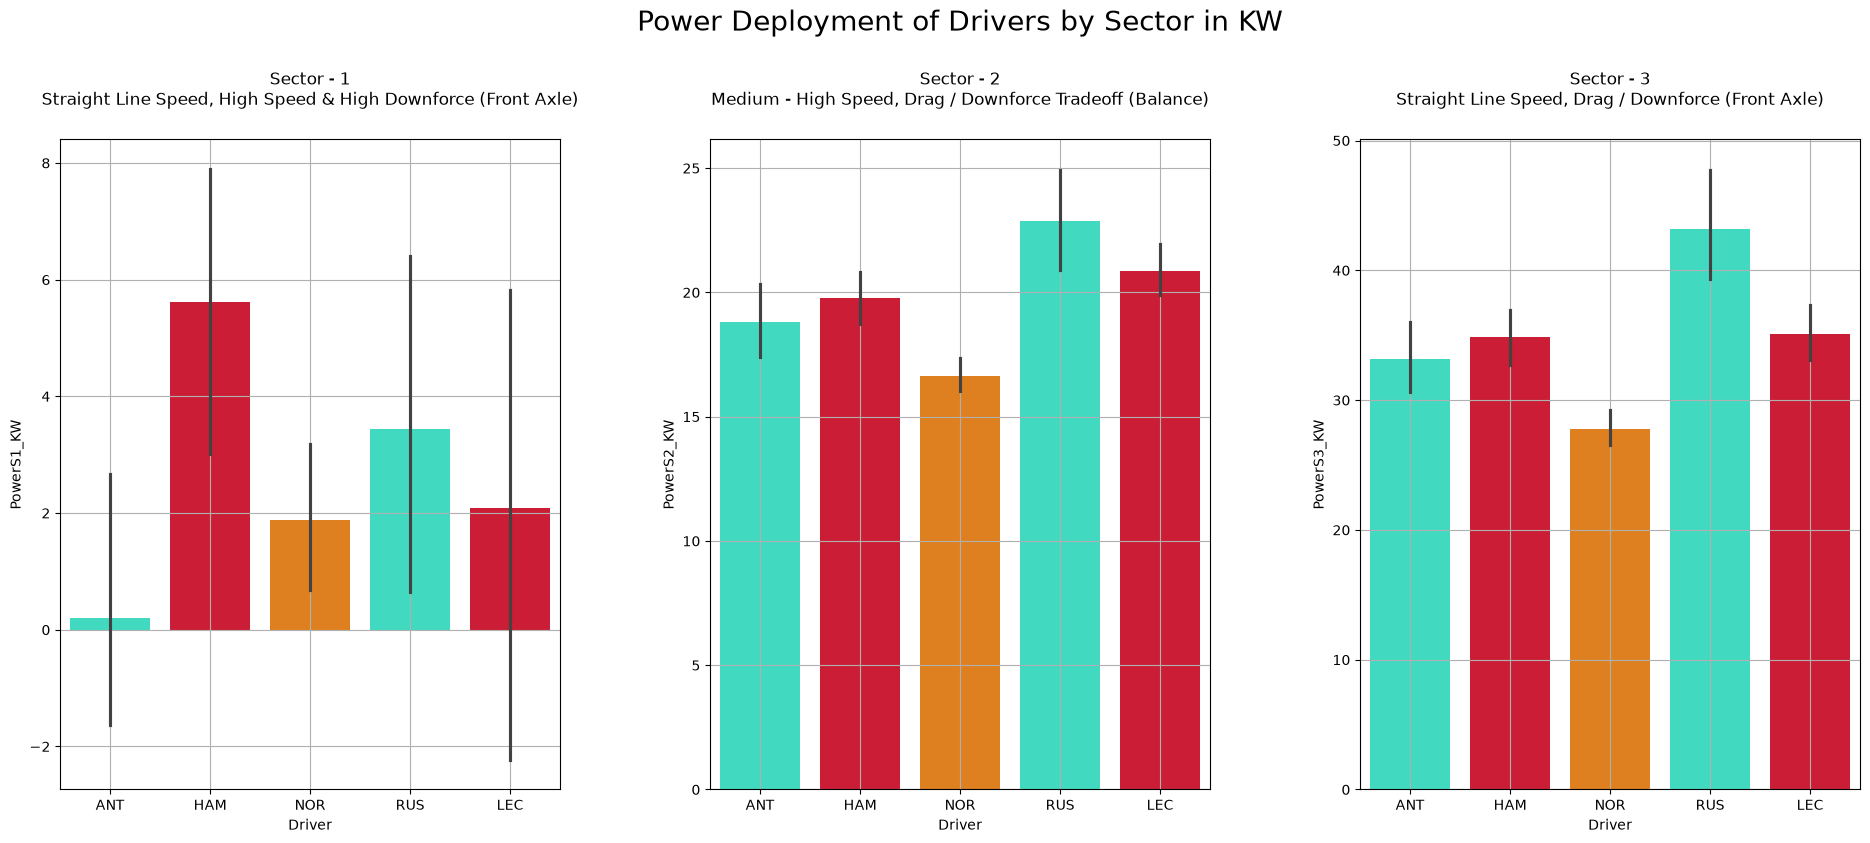

In [26]:
ke_grid = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=filtered_race_laps_wo,
    hue="Driver",
    plot_kind="power"
)

ke_grid.suptitle(
    t="Power Deployment of Drivers by Sector in KW",
    fontsize=20
)
plt.subplots_adjust(
    left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.3
)
plt.show()

### Quali Trim vs Race Trim

In [27]:
# Generating all the features
race_performance = data_pipe.get_mean_race_laps(
    laps_frame=filtered_race_laps,
    drivers=top_5_drivers.to_list()
)

# ================ Aero Features ================
race_performance.loc[:, "FrontAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI1"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector1Time"],
        purple_sector_time=race_performance["Sector1Time"].min()
    ),
    axis=1
)
race_performance.loc[:, "BalancedAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI2"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector2Time"],
        purple_sector_time=race_performance["Sector2Time"].min()
    ),
    axis=1
)
race_performance.loc[:, "RearAEI"] = race_performance.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedFL"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector3Time"],
        purple_sector_time=race_performance["Sector3Time"].min()
    ),
    axis=1
)

# ================ Kinetic Energy Features ================
race_performance.loc[:, "KineticEnergyS1_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
race_performance.loc[:, "KineticEnergyS2_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI2"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
race_performance.loc[:, "KineticEnergyS3_KJ"] = race_performance.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedFL"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# ================ Power Features ================
race_performance["PowerS1_KW"] = (
    race_performance["KineticEnergyS1_KJ"] / 
    race_performance["Sector1Time"]
)
race_performance["PowerS2_KW"] = (
    race_performance["KineticEnergyS2_KJ"] / 
    race_performance["Sector2Time"]
)
race_performance["PowerS3_KW"] = (
    race_performance["KineticEnergyS3_KJ"] / 
    race_performance["Sector3Time"]
)

# ================ Auxiliary Features ================
# ERS Clipping
race_performance["ERS_Clipping"] = race_performance["SpeedST"] / race_performance["SpeedI1"]

# Acceleration Time
race_performance.loc[:, "AccelerationTime"] = race_performance.apply(
    lambda x: data_pipe.get_delta_acceleration_time(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

race_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,ANT,29.626812,37.345471,25.325941,92.223375,303.000000,262.588235,253.823529,304.058824,0.276810,0.238427,0.231885,19.144175,699.898621,834.706656,0.646177,18.741192,32.958564,1.003494,7.709302
1,HAM,29.948125,37.117471,25.424176,92.461875,293.705882,259.705882,249.764706,303.117647,0.266265,0.237995,0.228001,167.301294,727.716109,878.563987,5.586370,19.605757,34.556242,1.032045,7.841514
2,LEC,29.832062,37.521235,25.602882,92.861125,302.529412,259.941176,251.941176,307.117647,0.271745,0.232578,0.225408,83.311790,796.775300,918.742330,2.792693,21.235316,35.884332,1.015166,7.676573
3,NOR,29.843125,37.410588,25.628294,92.759000,295.647059,259.294118,253.000000,298.117647,0.273479,0.239710,0.232957,43.691510,644.545303,740.581848,1.464039,17.228954,28.897040,1.008357,7.881910
4,RUS,29.920313,37.520059,25.461706,92.830875,307.058824,264.705882,248.529412,314.941176,0.268169,0.230965,0.218034,146.025454,867.271129,1114.547483,4.880479,23.114866,43.773480,1.025670,7.524116


In [28]:
# Rescaling the Features
quali_performance_rescaled = data_pipe.get_rescaled_direct_features(
    laps_frame=quali_performance
)
quali_performance_rescaled = data_pipe.get_rescaled_inverse_features(
    laps_frame=quali_performance_rescaled
)

race_performance_rescaled = data_pipe.get_rescaled_direct_features(
    laps_frame=race_performance
)
race_performance_rescaled = data_pipe.get_rescaled_inverse_features(
    laps_frame=race_performance_rescaled
)

race_performance

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,ANT,100.000010,43.531479,100.000010,100.000010,69.603534,60.869575,100.000010,35.314695,100.000010,85.328567,92.811803,100.000010,75.147339,74.830637,0.646177,18.741192,32.958564,100.000010,48.242177
1,HAM,0.000010,100.000010,67.509738,62.602911,0.000010,7.608706,23.333343,29.720290,0.000010,80.389027,66.786243,0.000010,62.657773,63.103000,5.586370,19.605757,34.556242,0.000010,11.290338
2,LEC,36.121387,0.000010,8.404679,0.000010,66.079305,11.956532,64.444454,53.496513,51.967545,18.445558,49.410841,56.689492,31.651404,52.359140,2.792693,21.235316,35.884332,59.118691,57.389773
3,NOR,32.678477,27.403856,0.000010,16.013338,14.537455,0.000010,84.444454,0.000010,68.408421,100.000010,100.000010,83.431563,100.000010,100.000010,1.464039,17.228954,28.897040,82.970197,0.000010
4,RUS,8.655914,0.291385,55.097286,4.743248,100.000010,100.000010,0.000010,100.000010,18.053744,0.000010,0.000010,14.360333,0.000010,0.000010,4.880479,23.114866,43.773480,22.326722,100.000010


In [29]:
polar_fig = data_vis.create_comparison_radar(
    quali_performance=quali_performance_rescaled,
    race_performance=race_performance_rescaled,
    drivers=top_5_drivers.to_list(),
    show_pace_categories=True,
    show_speed_categories=True,
    show_energy_categories=True,
)

polar_fig.show()

## Fin, Cheers!!!